In [2]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [3]:
df = pd.read_csv("/content/drive/MyDrive/data.csv")

In [4]:
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4600
Columns : 18


In [7]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [9]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [10]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(4600, 18)

In [14]:
df.dtypes

,0
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


In [15]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

date
70
----------------------------------------
price
1741
----------------------------------------
bedrooms
10
----------------------------------------
bathrooms
26
----------------------------------------
sqft_living
566
----------------------------------------
sqft_lot
3113
----------------------------------------
floors
6
----------------------------------------
waterfront
2
----------------------------------------
view
5
----------------------------------------
condition
5
----------------------------------------
sqft_above
511
----------------------------------------
sqft_basement
207
----------------------------------------
yr_built
115
----------------------------------------
yr_renovated
60
----------------------------------------
street
4525
----------------------------------------
city
44
----------------------------------------
statezip
77
----------------------------------------
country
1
----------------------------------------


In [16]:
df["price"].describe()

,price
count,4.600000e+03
mean,5.519630e+05
std,5.638347e+05
min,0.000000e+00
25%,3.228750e+05
50%,4.609435e+05
75%,6.549625e+05
max,2.659000e+07


In [17]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')

In [18]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [19]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,1522,36,62,0
1,0,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,3899,35,58,0
2,0,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,2291,18,26,0
3,0,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4263,3,7,0
4,0,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,4352,31,31,0


In [20]:
df.dtypes

,0
date,int64
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


In [21]:
corr = df.corr()

corr

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
date,1.000000,0.033906,0.005762,0.019263,0.029481,-0.020393,0.029607,0.017586,0.005844,0.007853,0.041038,-0.015050,0.001356,-0.018437,-0.005089,-0.020325,-0.004546,NaN
price,0.033906,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774,0.029366,0.018625,-0.043385,NaN
bedrooms,0.005762,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082,-0.035507,-0.130447,-0.152773,NaN
bathrooms,0.019263,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886,0.007175,-0.097026,-0.194497,NaN
sqft_living,0.029481,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817,0.006411,-0.109686,-0.198918,NaN
sqft_lot,-0.020393,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730,-0.023028,-0.079135,-0.128466,NaN
floors,0.029607,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996,0.056191,0.078481,-0.038943,NaN
waterfront,0.017586,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625,0.035448,0.001450,0.007938,NaN
view,0.005844,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967,0.065077,0.001340,0.079340,NaN
condition,0.007853,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818,-0.005480,-0.010592,0.027666,NaN


In [22]:
print("Dataset Cleaning Completed Successfully.")

Dataset Cleaning Completed Successfully.


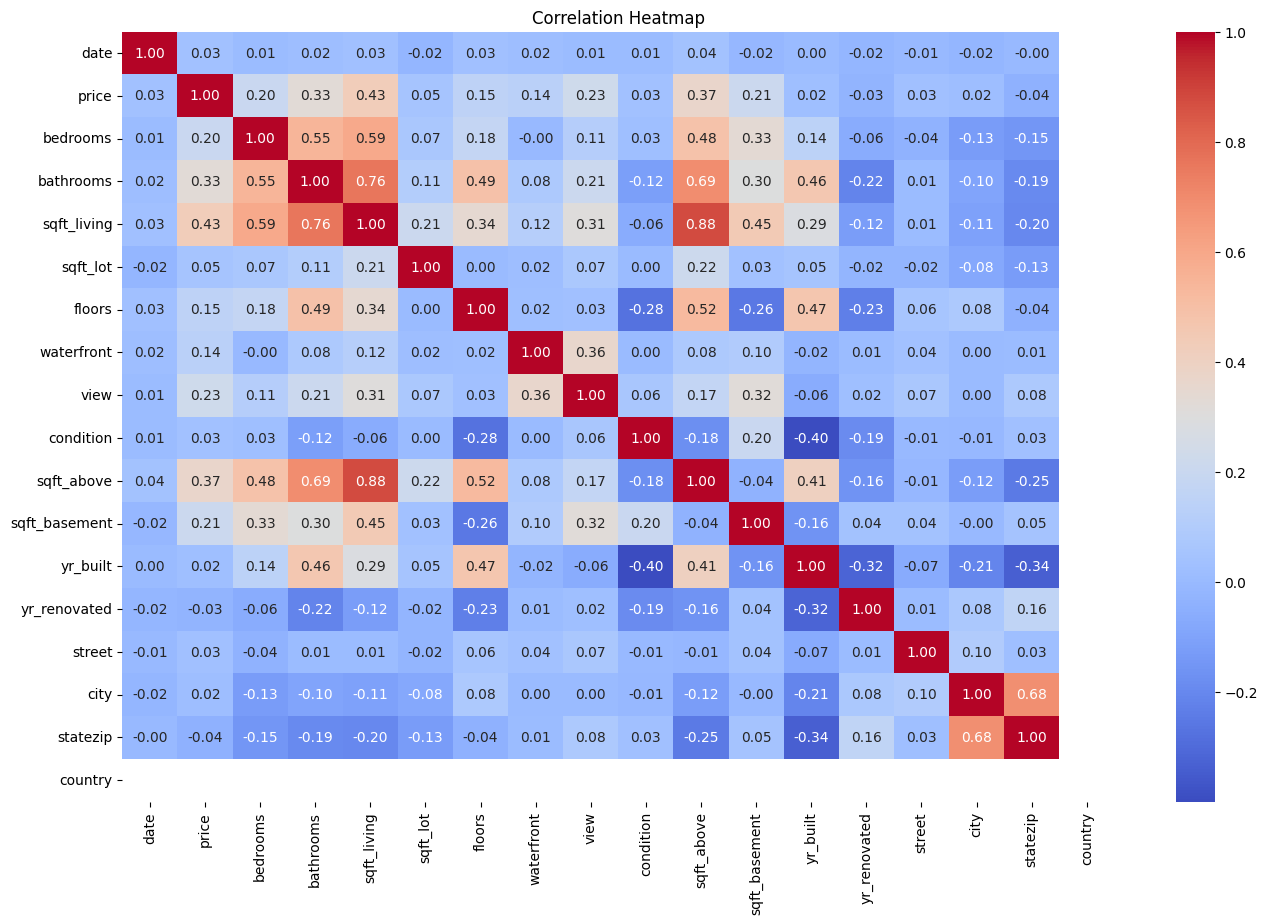

In [23]:
plt.figure(figsize=(16,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

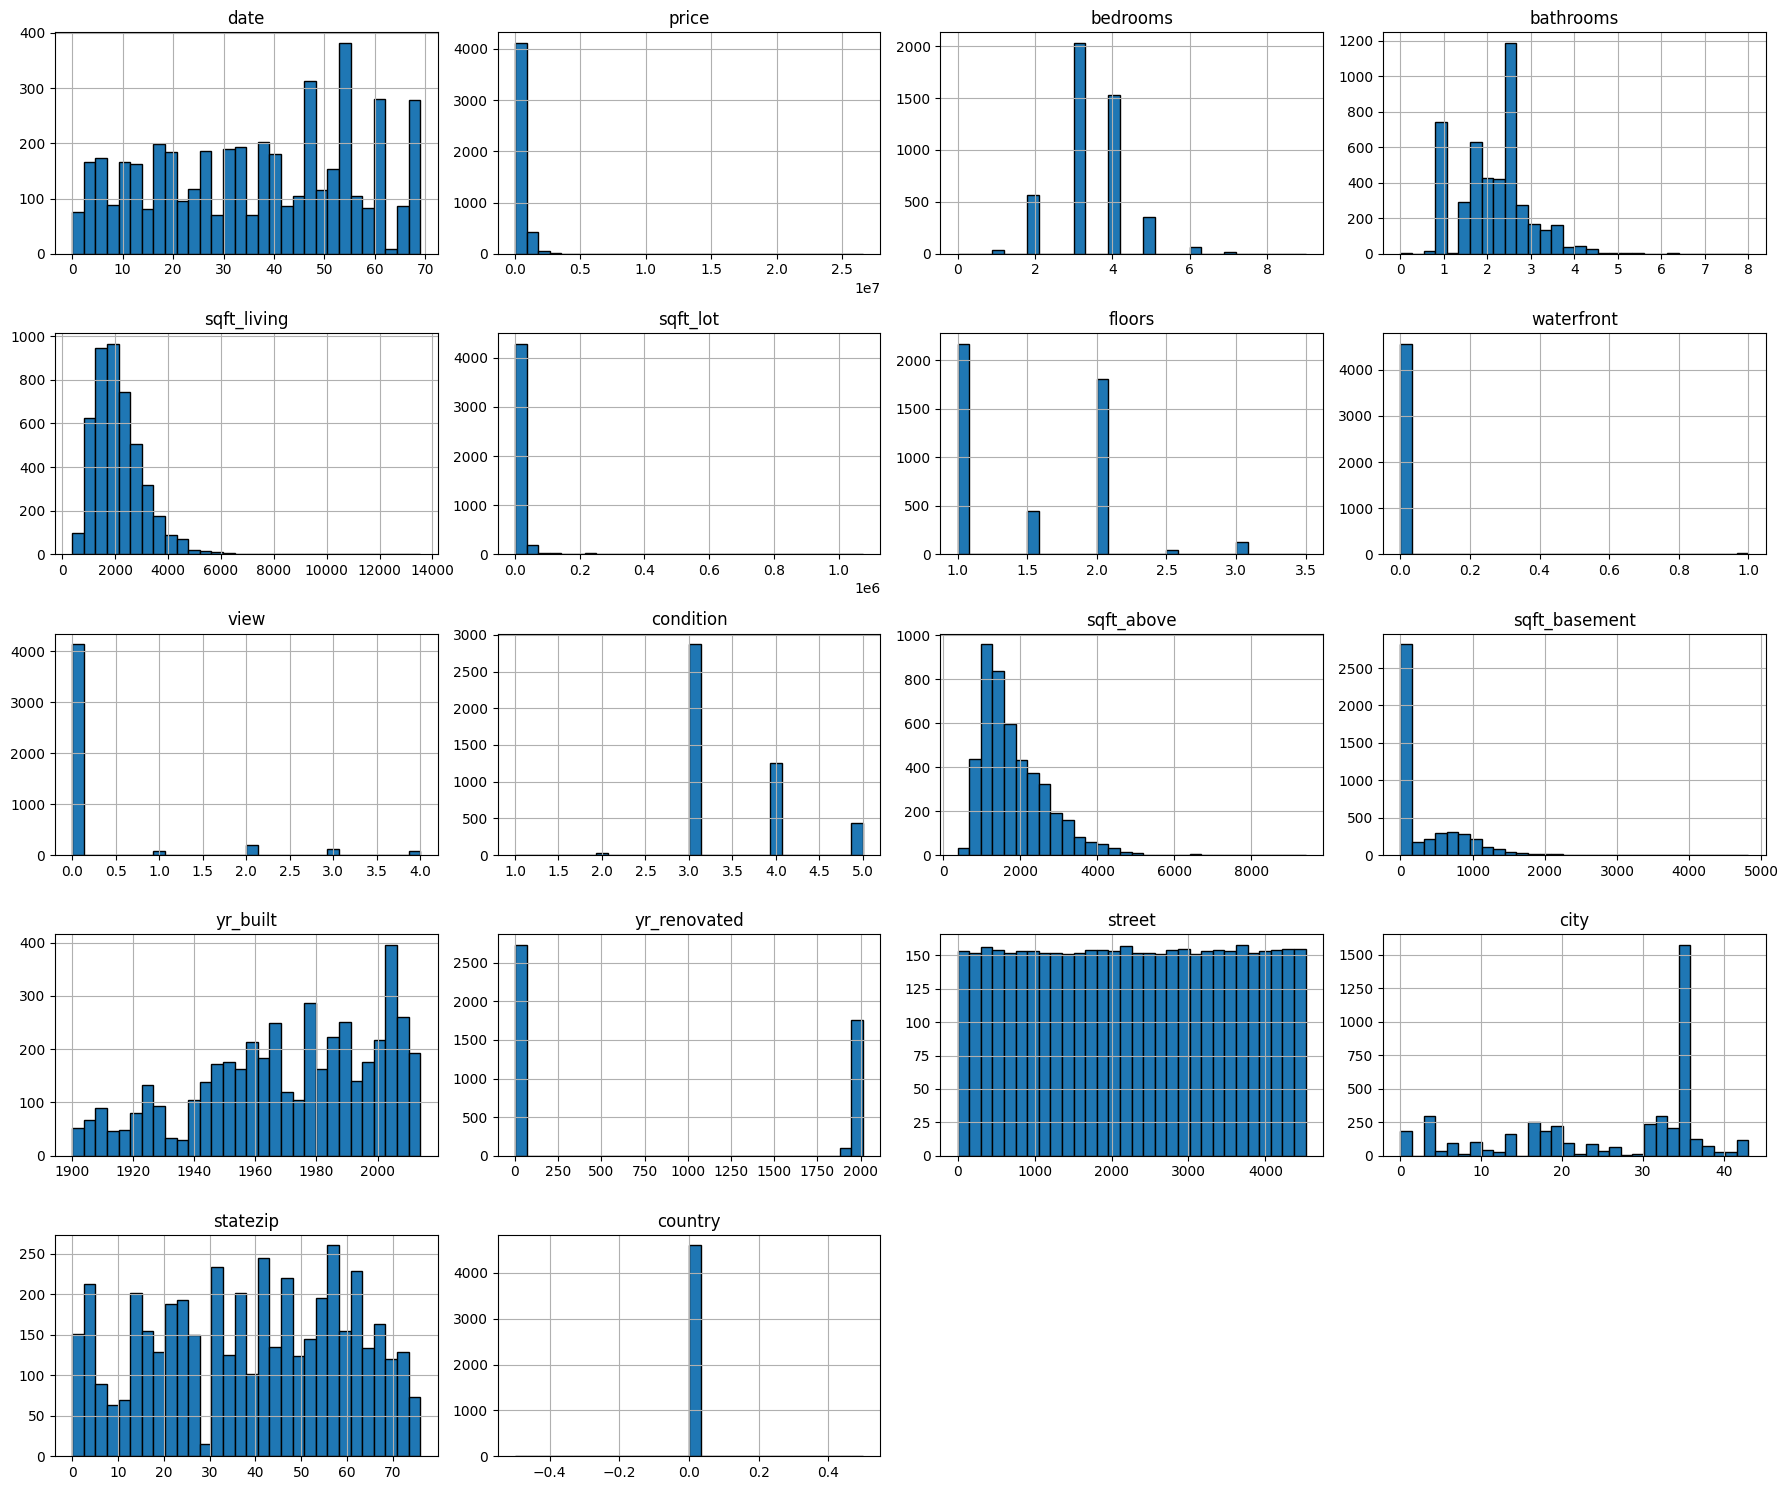

In [24]:
df.hist(figsize=(18,15),
        bins=30,
        edgecolor="black")

plt.tight_layout()
plt.show()

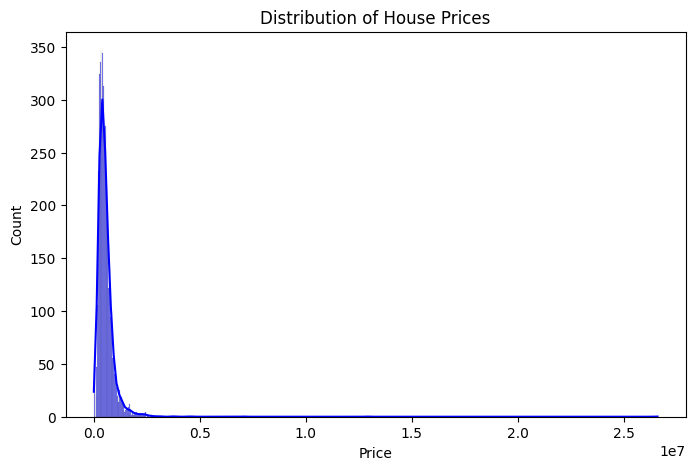

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"],
             kde=True,
             color="blue")

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

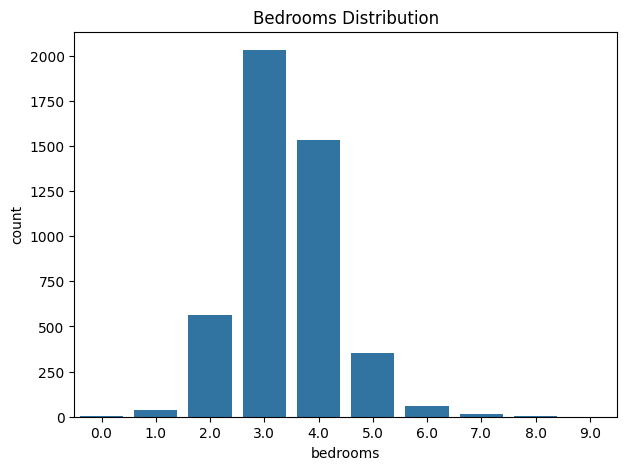

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x="bedrooms", data=df)

plt.title("Bedrooms Distribution")

plt.show()

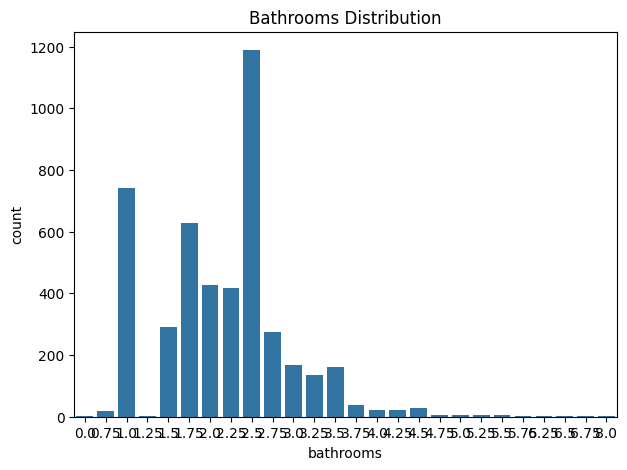

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(x="bathrooms", data=df)

plt.title("Bathrooms Distribution")

plt.show()

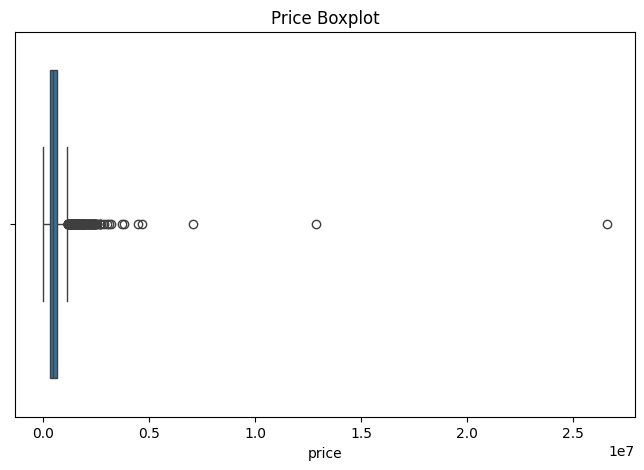

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Price Boxplot")

plt.show()

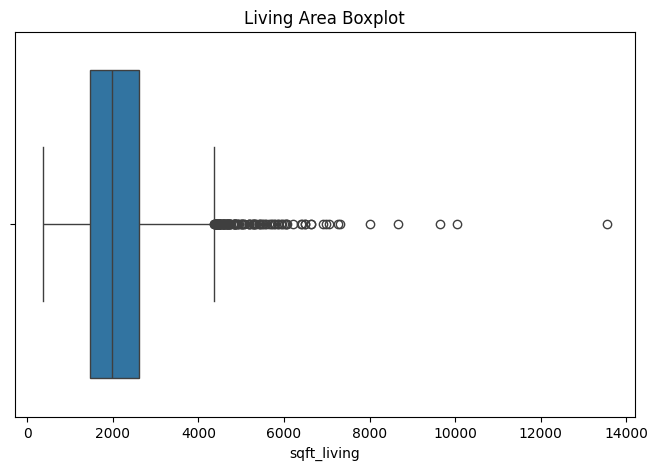

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["sqft_living"])

plt.title("Living Area Boxplot")

plt.show()

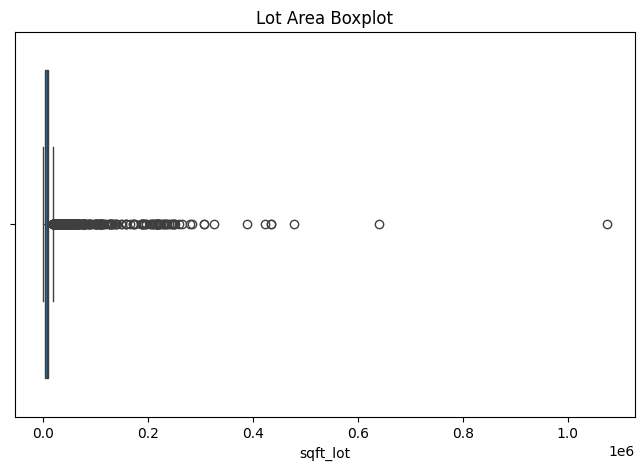

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["sqft_lot"])

plt.title("Lot Area Boxplot")

plt.show()

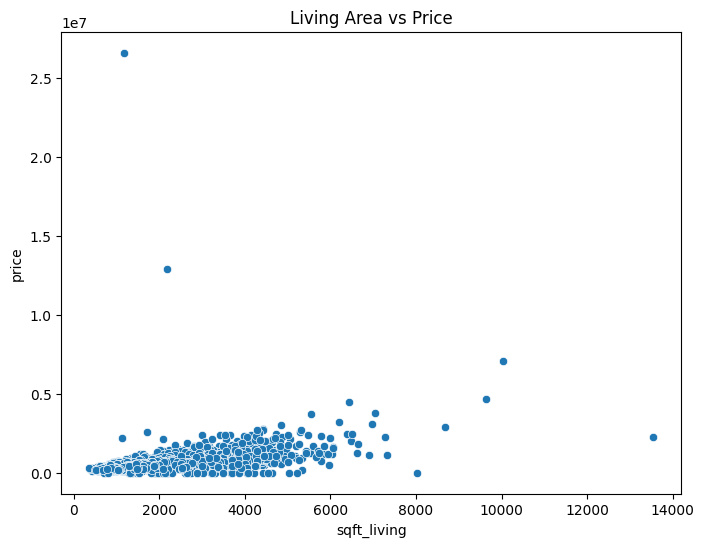

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="sqft_living",
    y="price",
    data=df
)

plt.title("Living Area vs Price")

plt.show()

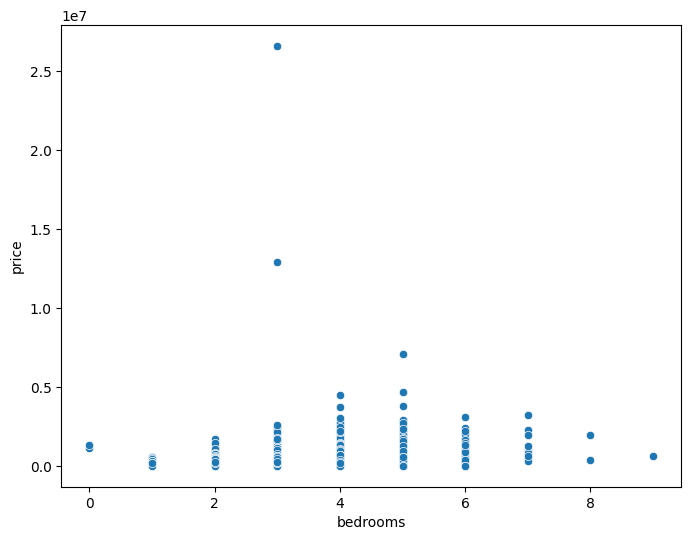

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="bedrooms",
    y="price",
    data=df
)

plt.show()

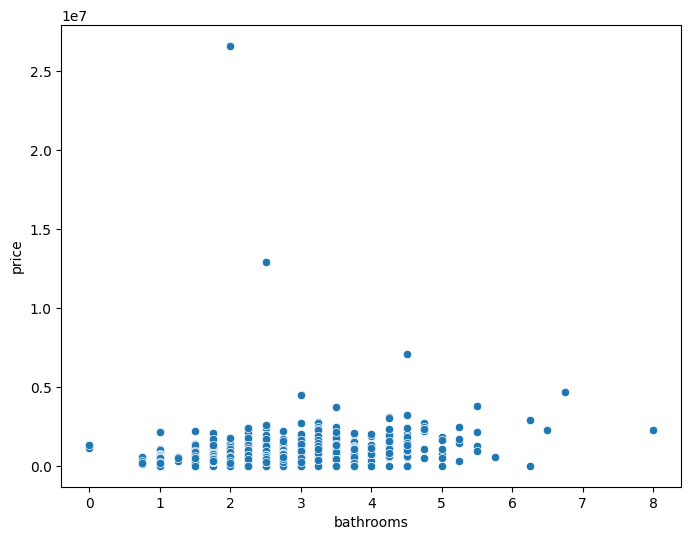

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="bathrooms",
    y="price",
    data=df
)

plt.show()

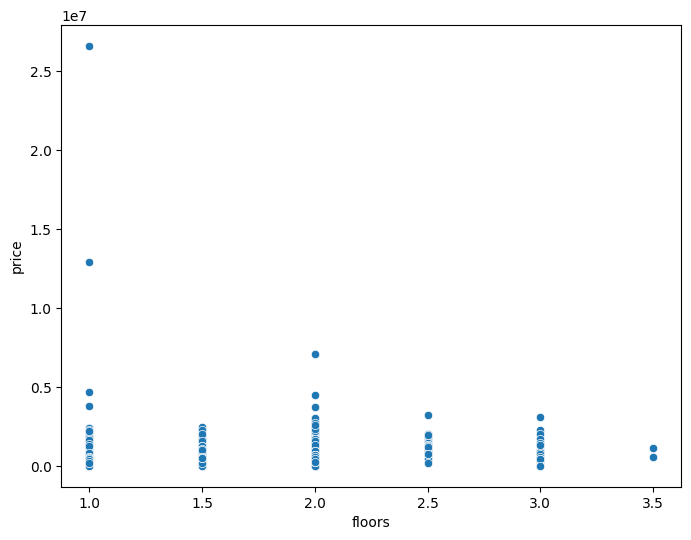

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="floors",
    y="price",
    data=df
)

plt.show()

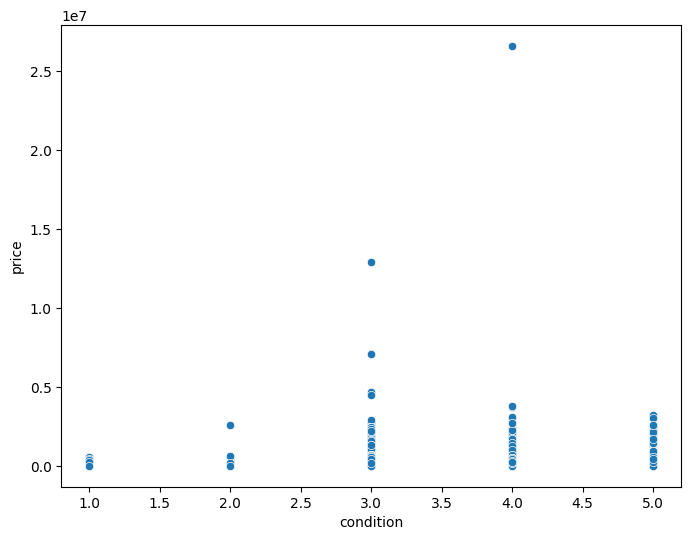

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="condition",
    y="price",
    data=df
)

plt.show()

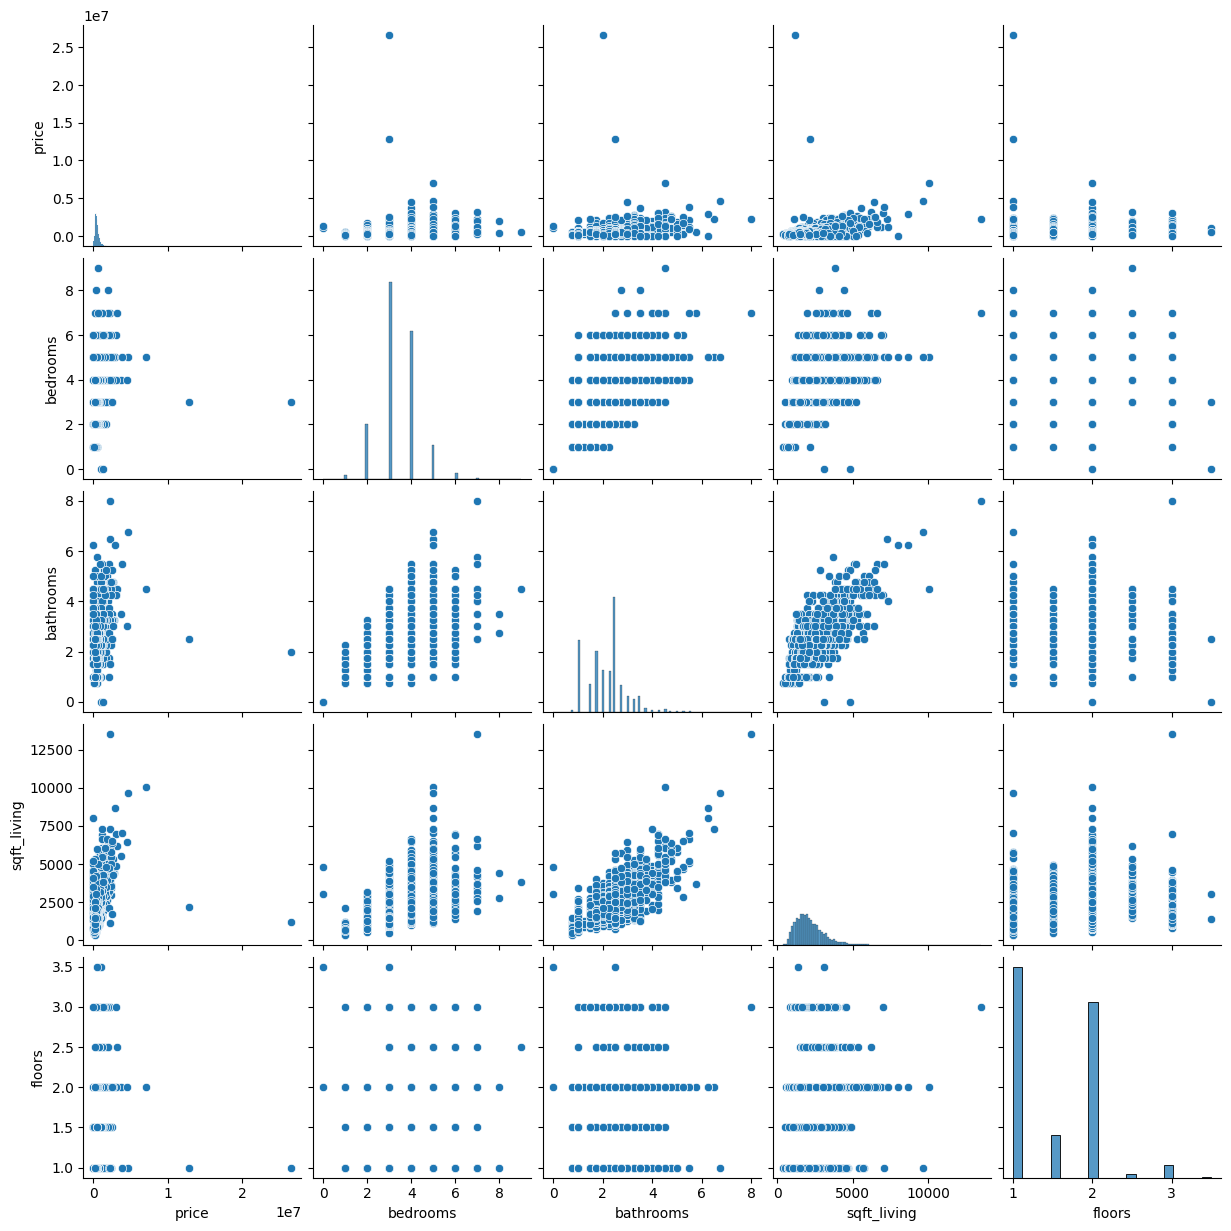

In [36]:
sns.pairplot(
    df[
        [
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "floors"
        ]
    ]
)

plt.show()

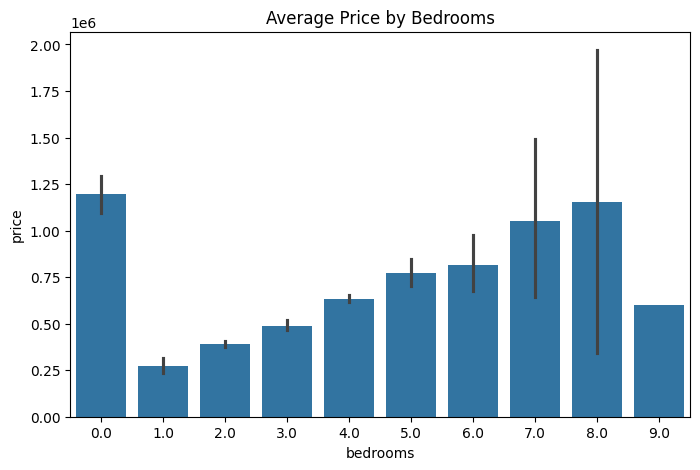

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="bedrooms",
    y="price",
    data=df
)

plt.title("Average Price by Bedrooms")

plt.show()

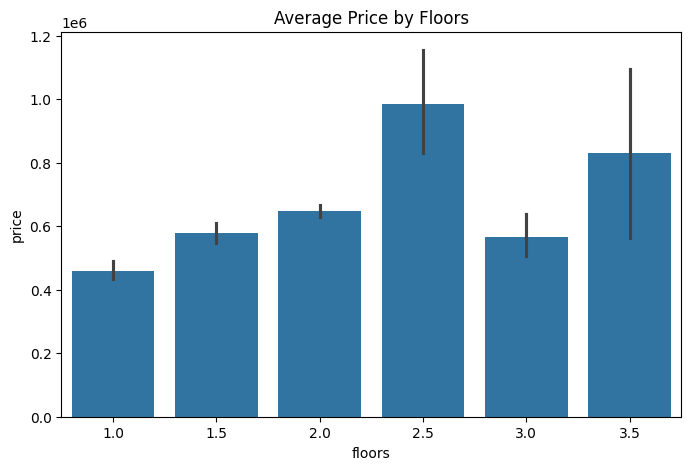

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="floors",
    y="price",
    data=df
)

plt.title("Average Price by Floors")

plt.show()

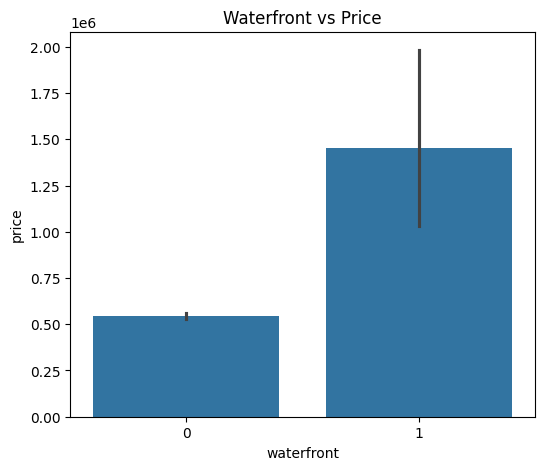

In [39]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="waterfront",
    y="price",
    data=df
)

plt.title("Waterfront vs Price")

plt.show()

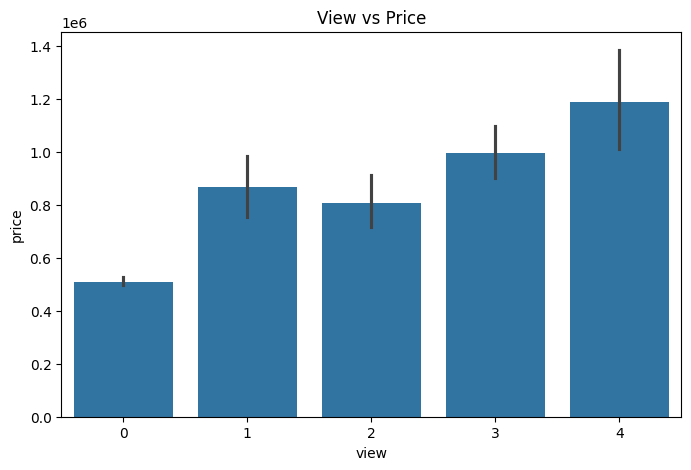

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="view",
    y="price",
    data=df
)

plt.title("View vs Price")

plt.show()

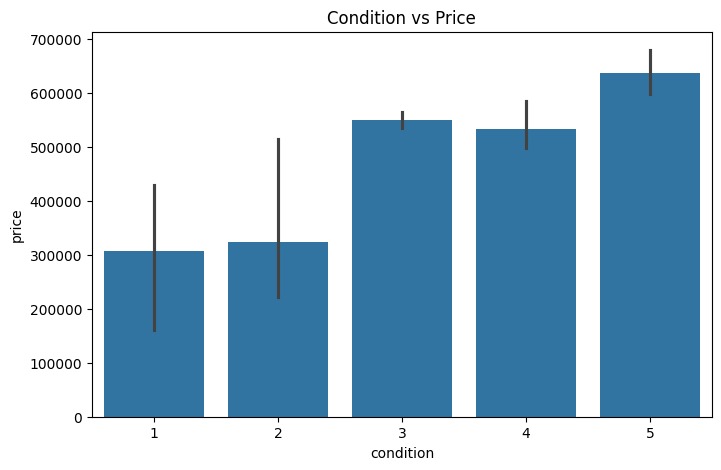

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="condition",
    y="price",
    data=df
)

plt.title("Condition vs Price")

plt.show()

In [42]:
corr = df.corr()["price"].sort_values(ascending=False)

print(corr)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
date             0.033906
street           0.029366
yr_built         0.021857
city             0.018625
yr_renovated    -0.028774
statezip        -0.043385
country               NaN
Name: price, dtype: float64


In [43]:
print("Exploratory Data Analysis Completed Successfully.")

Exploratory Data Analysis Completed Successfully.


In [44]:
# ==========================
# Separate Features & Target
# ==========================

X = df.drop("price", axis=1)

y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (4600, 17)
Target Shape : (4600,)


In [45]:
print(X.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'],
      dtype='object')


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (3680, 17)
Testing Data : (920, 17)


In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
print(X_train_scaled[:5])

[[-0.17345936  0.67051991  0.43690203  0.66097147  0.87005417  0.91040303
  -0.085972   -0.30619401  0.80882987  1.10517908 -0.67958227  0.62672137
  -0.82244584 -0.57770347  1.36120159  0.24615061  0.        ]
 [-0.58120797  0.67051991  1.07491769  1.65201056  0.40680186  0.91040303
  -0.085972   -0.30619401 -0.67201288  2.21118514 -0.67958227  0.6939252
  -0.82244584 -1.68570134 -0.56874636 -0.85084748  0.        ]
 [ 0.79494359  0.67051991  0.43690203  0.70269944 -0.09728842  0.91040303
  -0.085972   -0.30619401 -0.67201288  1.15174776 -0.67958227  0.39150796
  -0.82244584 -0.29002083  0.60600457  0.15075947  0.        ]
 [ 0.23428925  0.67051991  2.03194118  1.97540226 -0.10628853  0.91040303
  -0.085972   -0.30619401 -0.67201288  2.57209238 -0.67958227  1.19795392
  -0.82244584  1.1094751  -0.56874636 -0.85084748  0.        ]
 [-1.65154808 -0.43006585 -0.20111363 -0.14229178 -0.21316478  0.91040303
  -0.085972   -0.30619401 -0.67201288  0.20873207 -0.67958227 -1.82621842
   1.2067

In [49]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [50]:
linear_predictions = linear_model.predict(X_test_scaled)

linear_predictions[:10]

array([ 316064.67583703,  315217.37023824, 1071220.92321242,
        560198.39177539,  385891.77756425,  585752.1202759 ,
        455468.77878571,  421234.15540835,  501295.50814073,
        550373.79077898])

In [51]:
lr_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

print("MAE :", lr_mae)

MAE : 207816.8294166553


In [52]:
lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

print("RMSE :", lr_rmse)

RMSE : 993048.575350367


In [53]:
lr_r2 = r2_score(
    y_test,
    linear_predictions
)

print("R2 Score :", lr_r2)

R2 Score : 0.03304504390209173


In [54]:
gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gbr.fit(
    X_train_scaled,
    y_train
)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [55]:
gbr_predictions = gbr.predict(
    X_test_scaled
)

gbr_predictions[:10]

array([ 464708.56309804,  296269.1133646 , 1078369.67697909,
        483355.48334334,  302996.9449163 ,  571570.30759438,
        447779.85548468,  398911.71039942,  511640.43528053,
        619530.88080164])

In [56]:
gbr_mae = mean_absolute_error(
    y_test,
    gbr_predictions
)

print("MAE :", gbr_mae)

MAE : 171531.51903222667


In [57]:
gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gbr_predictions
    )
)

print("RMSE :", gbr_rmse)

RMSE : 983319.2474878537


In [58]:
gbr_r2 = r2_score(
    y_test,
    gbr_predictions
)

print("R2 Score :", gbr_r2)

R2 Score : 0.05189958087447066


In [59]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Gradient Boosting"
    ],

    "MAE":[
        lr_mae,
        gbr_mae
    ],

    "RMSE":[
        lr_rmse,
        gbr_rmse
    ],

    "R2 Score":[
        lr_r2,
        gbr_r2
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,207816.829417,993048.575350,0.033045
1,Gradient Boosting,171531.519032,983319.247488,0.051900


In [60]:
best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
1,Gradient Boosting,171531.519032,983319.247488,0.051900
0,Linear Regression,207816.829417,993048.575350,0.033045


In [61]:
joblib.dump(
    scaler,
    "feature_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [62]:
joblib.dump(
    gbr,
    "house_price_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [63]:
print("Model Training Completed Successfully")

Model Training Completed Successfully


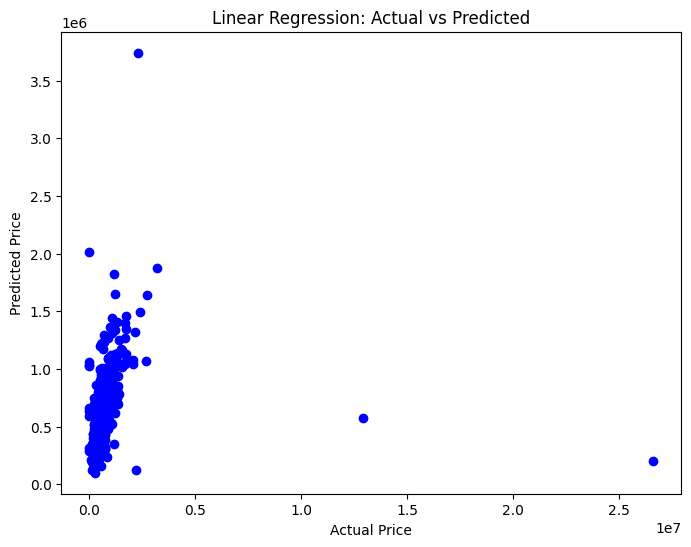

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_predictions, color="blue")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

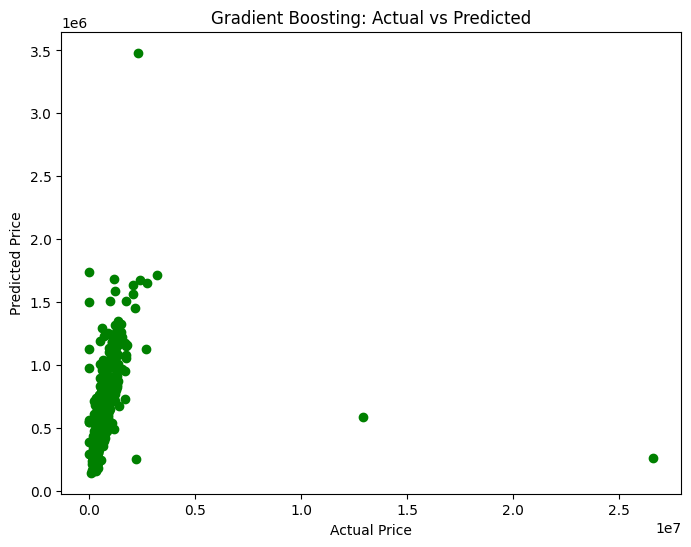

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gbr_predictions, color="green")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

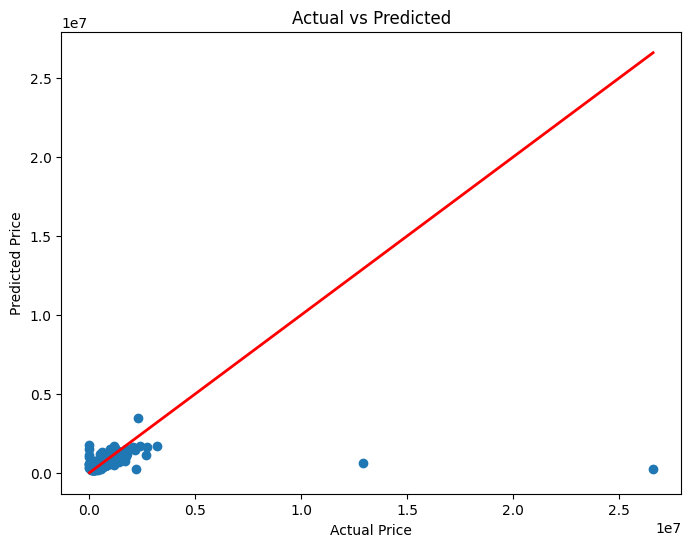

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gbr_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

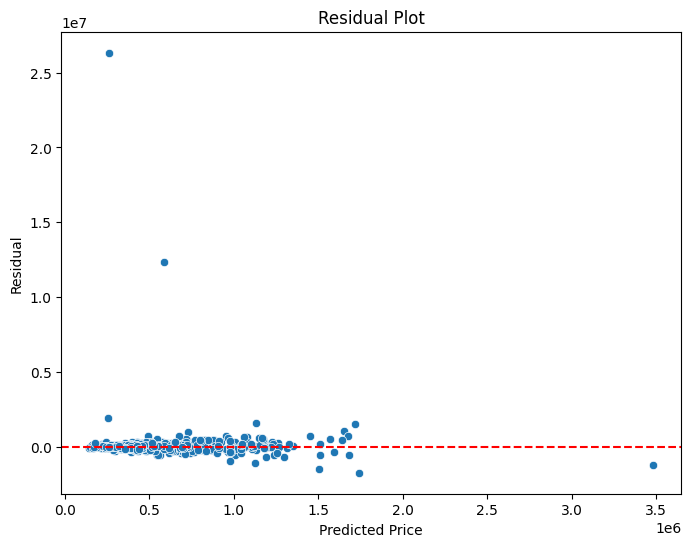

In [67]:
residuals = y_test - gbr_predictions

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=gbr_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [68]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":gbr.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,sqft_living,0.619676
15,statezip,0.119065
14,city,0.047406
11,yr_built,0.044597
9,sqft_above,0.044105
7,view,0.041883
10,sqft_basement,0.021619
2,bathrooms,0.016594
4,sqft_lot,0.014348
13,street,0.009562


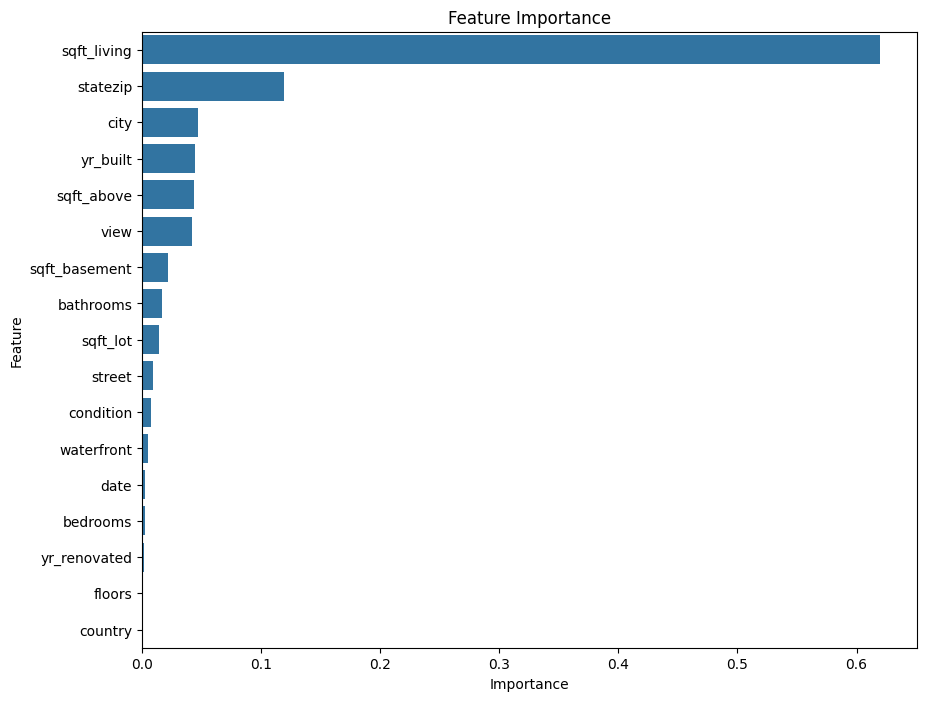

In [69]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [70]:
importance.head(10)

,Feature,Importance
3,sqft_living,0.619676
15,statezip,0.119065
14,city,0.047406
11,yr_built,0.044597
9,sqft_above,0.044105
7,view,0.041883
10,sqft_basement,0.021619
2,bathrooms,0.016594
4,sqft_lot,0.014348
13,street,0.009562


In [71]:
sample_house = pd.DataFrame({

    "date":[0],
    "bedrooms":[3],
    "bathrooms":[2],
    "sqft_living":[2000],
    "sqft_lot":[5000],
    "floors":[2],
    "waterfront":[0],
    "view":[1],
    "condition":[3],
    "sqft_above":[1800],
    "sqft_basement":[200],
    "yr_built":[2005],
    "yr_renovated":[0],
    "street":[0],
    "city":[0],
    "statezip":[0],
    "country":[0]

})

In [72]:
sample_scaled = scaler.transform(sample_house)

In [73]:
prediction = gbr.predict(sample_scaled)

print("Predicted House Price : $", prediction[0])

Predicted House Price : $ 371679.2156224362


In [74]:
joblib.dump(

    gbr,

    "HousePricePredictionModel.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
joblib.dump(

    scaler,

    "Scaler.pkl"

)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [76]:
loaded_model = joblib.load(

    "HousePricePredictionModel.pkl"

)

loaded_model

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [77]:
loaded_scaler = joblib.load(

    "Scaler.pkl"

)

loaded_scaler

StandardScaler()

In [78]:
sample_scaled = loaded_scaler.transform(sample_house)

price = loaded_model.predict(sample_scaled)

print(price)

[371679.21562244]


In [79]:
from google.colab import files

files.download("HousePricePredictionModel.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
files.download("Scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
print("="*60)

print("Linear Regression")

print("MAE :",lr_mae)

print("RMSE :",lr_rmse)

print("R2 :",lr_r2)

print("="*60)

print("Gradient Boosting")

print("MAE :",gbr_mae)

print("RMSE :",gbr_rmse)

print("R2 :",gbr_r2)

print("="*60)

Linear Regression
MAE : 207816.8294166553
RMSE : 993048.575350367
R2 : 0.03304504390209173
Gradient Boosting
MAE : 171531.51903222667
RMSE : 983319.2474878537
R2 : 0.05189958087447066


In [82]:
if gbr_r2 > lr_r2:

    print("Gradient Boosting performed better.")

else:

    print("Linear Regression performed better.")

Gradient Boosting performed better.


In [83]:
print("House Price Prediction Project Completed Successfully.")

House Price Prediction Project Completed Successfully.


In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
